In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'X vs y')

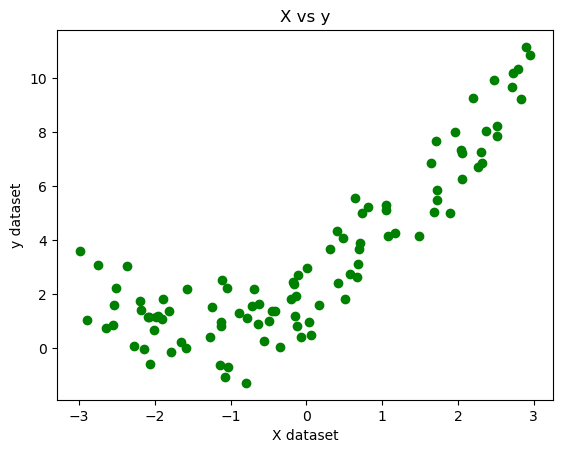

In [2]:
X=6*np.random.rand(100,1)-3
y=0.5*X**2+1.5*X+2+np.random.randn(100,1)
plt.scatter(X,y,color="green")
plt.xlabel("X dataset")
plt.ylabel("y dataset")
plt.title("X vs y")

In [3]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
#standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

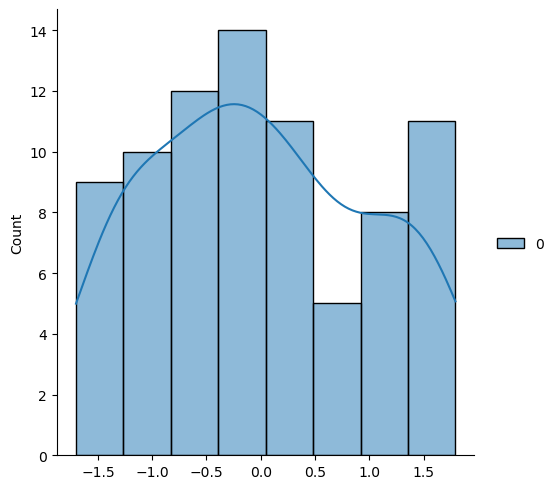

In [5]:
import seaborn as sns
sns.displot(X_train,kde=True)

In [6]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [7]:
regression.fit(X_train,y_train)
y_pred=regression.predict(X_test)


In [8]:
from sklearn.metrics import mean_squared_error, r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(r2,mse)

0.6392191768074419 3.4605387985864637


Text(0, 0.5, 'y dataset')

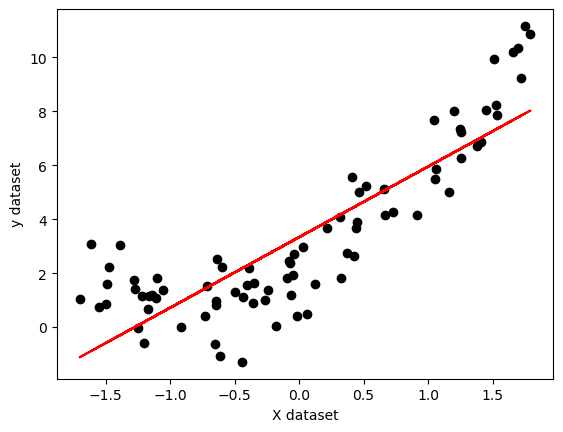

In [9]:
plt.plot(X_train,regression.predict(X_train),color="red")#predicted values
plt.scatter(X_train,y_train,color="black")#actual values
plt.xlabel("X dataset")
plt.ylabel("y dataset")

In [10]:
#polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test) 

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred_poly=regression.predict(X_test_poly)
mse=mean_squared_error(y_test,y_pred_poly)
r2=r2_score(y_test,y_pred_poly)
print(r2)


0.8789920565158129


In [12]:
regression.coef_

array([[0.        , 2.40759408, 1.34892357]])

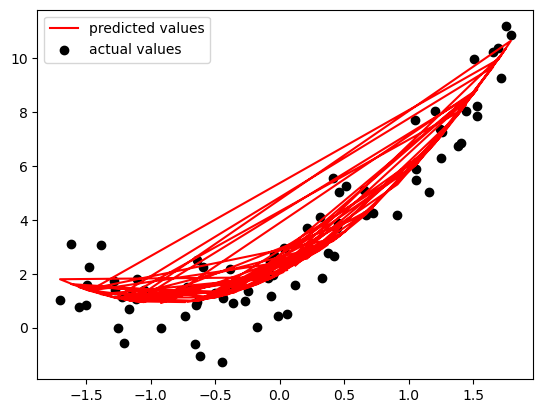

In [13]:
plt.plot(X_train,regression.predict(X_train_poly),color="red")
plt.scatter(X_train,y_train,color="black")
plt.legend(["predicted values","actual values"])

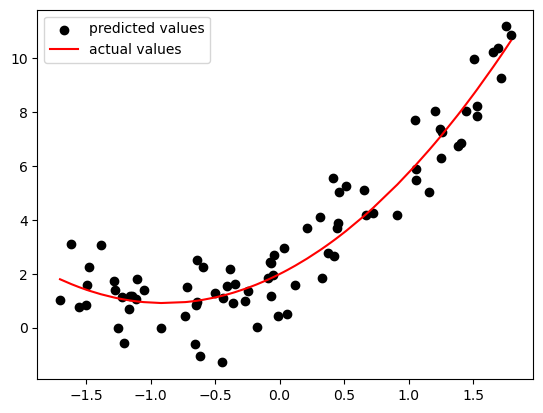

In [14]:
sorted_array = X_train.flatten().argsort()
plt.scatter(X_train,y_train,color="black")

plt.plot(
    X_train.flatten()[sorted_array],
    regression.predict(X_train_poly).flatten()[sorted_array],
    color="red"
)

plt.legend(["predicted values","actual values"])




# PIPELINE CONCEPTS

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [16]:
def polynomial_regression(degree):
    X_new=np.linspace(-3,3,200).reshape(200,1)
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new,y_pred_new,"r",label="Degree "+str(degree))
    plt.plot(X_train,y_train,"o",color="black",label="Actual values")
    plt.plot(X_test,y_test,"o",color="green",label="Test values")
    plt.xlabel("X dataset")
    plt.ylabel("y dataset")
    plt.legend(loc="upper left")
    plt.show()




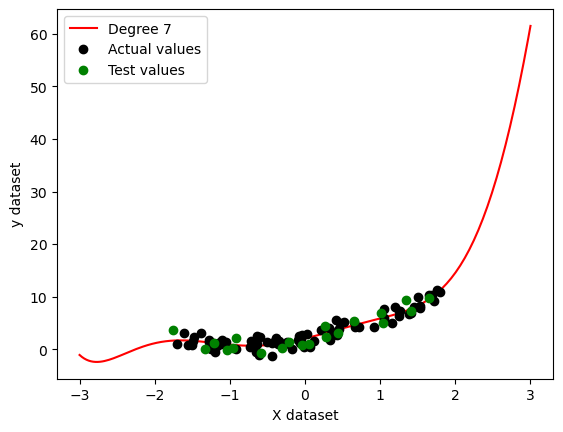

In [23]:
polynomial_regression(7)